# **Análisis de grandes volúmenes de datos (TC4034)**

## Maestría en Inteligencia Artificial Aplicada
### Ivan Olmos Pineda | Perla A. García Aguirre
### Tecnológico de Monterrey
## **Proyecto | Base de Datos de Big Data**

---

### Team 8

- Michelle Andrea Arceo Solano — A01625268
- Jacobo Daniel Salazar García — A01796997
- Ariel Antonio Alvarez Monroy — A01796838
- Omar Aguilar Macedo - A01797078

# Descripción del proyecto

## NYC Taxi Trip Records

## Contexto del Dataset

El dataset **NYC Taxi Trip Records** contiene información detallada sobre los viajes realizados por taxis en la ciudad de Nueva York. Cada registro representa un viaje individual e incluye variables relacionadas con tiempo, ubicación, distancia y costo del servicio.

Este dataset es ampliamente utilizado en proyectos de Big Data debido a su gran volumen, riqueza de variables y aplicabilidad en análisis de patrones urbanos, predicción y segmentación.

| Atributo         | Detalle |
|------------------|---------|
| **Nombre**       | NYC Yellow Taxi Trip Data |
| **Origen**       | Taxi & Limousine Commission (TLC) — NYC Government |
| **Fuente oficial**| https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page |
| **Diccionario de datos**| https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf |
| **Tabla de zonas (lookup)**| https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv |
| **Período a analizar**      | Enero 2023 — Marzo 2026 |
| **Tamaño total** | ~2.5 GB (139,279,754 registros, 24 columnas) |
| **Tamaño por archivo mensual** | ~45MB - 70MB (Parquet)   |
| **Formato**      | parquet |




## Tipos de Datos Disponibles

El dataset está dividido en diferentes categorías según el tipo de servicio:

- Yellow Taxi Trips  
- Green Taxi Trips  
- For-Hire Vehicle (FHV) Trips  
- High Volume FHV (Uber, Lyft, etc.)

Para este proyecto se seleccionó: **Yellow Taxi Trips**

## Formato y Acceso

Los datos están disponibles en formato `Parquet`

Este formato resulta eficiente, ya que se puede comprimir, permite lectura de columnas, y tiene un mejor rendimiento al usarse con PySpark

Ejemplo de archivo:
- https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet



# Preparación del entorno

In [1]:
# @title Dataset Imports
import os
import requests
from pathlib import Path

In [2]:
# @title Conectar a google drive
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [3]:
#@title Validación de Java
!java --version
!which java

openjdk 17.0.18 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
/usr/bin/java


In [4]:
#@title Agregamos JAVA_HOME

# Solo para linux :S, por lo que funciona en colab
JAVA_HOME=!java -XshowSettings:properties -version 2>&1 > /dev/null | grep 'java.home' | awk '{print $NF}'
JAVA_HOME=JAVA_HOME[0] # El comando anterior regresa un arreglo
%env JAVA_HOME=$JAVA_HOME

env: JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64


In [5]:
#@title Configuración e instalación de PySpark
!pip install pyspark
!pip install findspark

In [6]:
#@title PySpark imports
import findspark
from pyspark.sql import SparkSession

from pyspark.sql import functions as F
from pyspark.sql import types as T
from functools import reduce
import glob

# Para cargar algunos datasets estadísticos simples
import pandas as pd

# Para crear graficos simples
import matplotlib.pyplot as plt

# Descarga y lectura del dataset

In [7]:
# @title Descargar Dataset

# drive_dir = "/content/drive/MyDrive/TC4034_BigData/proyecto/taxi/yellow"

drive_dir = '/content/drive/MyDrive/TC4034.10 - Análisis de grandes volúmenes de datos (Gpo 10) | Equipo 8/raw/taxi/yellow'

In [8]:
#@title Leer el dataset

spark = (
    SparkSession.builder
    .appName("NYC Yellow Taxi")
    .getOrCreate()
)

parquet_files = glob.glob(f"{drive_dir}/*.parquet")

print(f"Archivos encontrados: {len(parquet_files)}")

dfs = []

for file in parquet_files:
    temp_df = spark.read.parquet(file)

    # Homologar tipos de datos entre archivos
    temp_df = temp_df.withColumn("VendorID", F.col("VendorID").cast(T.ByteType())) \
                     .withColumn("tpep_pickup_datetime", F.col("tpep_pickup_datetime")) \
                     .withColumn("tpep_dropoff_datetime", F.col("tpep_dropoff_datetime")) \
                     .withColumn("passenger_count", F.col("passenger_count").cast(T.ByteType())) \
                     .withColumn("trip_distance", F.col("trip_distance").cast(T.FloatType())) \
                     .withColumn("RatecodeID", F.col("RatecodeID").cast(T.ByteType())) \
                     .withColumn("store_and_fwd_flag", F.col("store_and_fwd_flag")) \
                     .withColumn("PULocationID", F.col("PULocationID").cast(T.ShortType())) \
                     .withColumn("DOLocationID", F.col("DOLocationID").cast(T.ShortType())) \
                     .withColumn("payment_type", F.col("payment_type").cast(T.ByteType())) \
                     .withColumn("fare_amount", F.col("fare_amount").cast(T.FloatType())) \
                     .withColumn("extra", F.col("extra").cast(T.FloatType())) \
                     .withColumn("mta_tax", F.col("mta_tax").cast(T.FloatType())) \
                     .withColumn("tip_amount", F.col("tip_amount").cast(T.FloatType())) \
                     .withColumn("tolls_amount", F.col("tolls_amount").cast(T.FloatType())) \
                     .withColumn("improvement_surcharge", F.col("improvement_surcharge").cast(T.FloatType())) \
                     .withColumn("total_amount", F.col("total_amount").cast(T.FloatType())) \
                     .withColumn("congestion_surcharge", F.col("congestion_surcharge").cast(T.FloatType())) \
                     .withColumn("Airport_fee", F.col("Airport_fee").cast(T.FloatType()))

    dfs.append(temp_df)

# Unir todos los archivos ya homologados
df = reduce(lambda a, b: a.unionByName(b, allowMissingColumns=True), dfs)

df.printSchema()

Archivos encontrados: 39
root
 |-- VendorID: byte (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: byte (nullable = true)
 |-- trip_distance: float (nullable = true)
 |-- RatecodeID: byte (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: short (nullable = true)
 |-- DOLocationID: short (nullable = true)
 |-- payment_type: byte (nullable = true)
 |-- fare_amount: float (nullable = true)
 |-- extra: float (nullable = true)
 |-- mta_tax: float (nullable = true)
 |-- tip_amount: float (nullable = true)
 |-- tolls_amount: float (nullable = true)
 |-- improvement_surcharge: float (nullable = true)
 |-- total_amount: float (nullable = true)
 |-- congestion_surcharge: float (nullable = true)
 |-- Airport_fee: float (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



# Preprocesamiento

In [9]:
#@title Crear columnas derivadas

df = df.withColumn(
        "pickup_year",
        F.year("tpep_pickup_datetime").cast("short")
    ) \
    .withColumn(
        "pickup_month",
        F.month("tpep_pickup_datetime").cast("byte")
    ) \
    .withColumn(
        "pickup_hour",
        F.hour("tpep_pickup_datetime").cast("byte")
    ) \
    .withColumn(
        "trip_duration_minutes",
        F.round(
            (
                F.unix_timestamp("tpep_dropoff_datetime") -
                F.unix_timestamp("tpep_pickup_datetime")
            ) / 60,
            1
        ) #.cast("float")
    )

In [10]:
df.printSchema()

root
 |-- VendorID: byte (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: byte (nullable = true)
 |-- trip_distance: float (nullable = true)
 |-- RatecodeID: byte (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: short (nullable = true)
 |-- DOLocationID: short (nullable = true)
 |-- payment_type: byte (nullable = true)
 |-- fare_amount: float (nullable = true)
 |-- extra: float (nullable = true)
 |-- mta_tax: float (nullable = true)
 |-- tip_amount: float (nullable = true)
 |-- tolls_amount: float (nullable = true)
 |-- improvement_surcharge: float (nullable = true)
 |-- total_amount: float (nullable = true)
 |-- congestion_surcharge: float (nullable = true)
 |-- Airport_fee: float (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-- pickup_year: short (nullable = true)
 |-- pickup_month: byte (nullable = true)
 |-- pick

In [11]:
#@title Dimensiones generales, del dataset original

total_records = df.count()
total_columns = len(df.columns)
size_in_bytes = df._jdf.queryExecution().optimizedPlan().stats().sizeInBytes()
print(f"Número de registros: {total_records:,}")
print(f"Información de columnas: {total_columns}")
print(f"Tamaño aproximado: ~{(size_in_bytes / 1024 / 1024 / 1024):.02f} GB")


Número de registros: 139,279,754
Información de columnas: 24
Tamaño aproximado: ~1.50 GB


## Detección de valores inválidos

Se aplicó una limpieza mínima orientada a remover registros físicamente imposibles o altamente atípicos. Se eliminaron viajes con duración negativa y distancias extremadamente grandes, ya que estos valores afectan la distribución general del dataset y pueden introducir sesgos en el análisis exploratorio. Otros valores potencialmente atípicos, como tarifas negativas o distancias iguales a cero, fueron conservados debido a que podrían representar casos válidos dentro de la operación real del servicio (como reembolsos, cancelaciones, etc).


In [12]:
quality_summary = df.select(
    F.count("*").alias("total_records"),
    F.sum(F.when(F.col("trip_distance") == 0, 1).otherwise(0)).alias("zero_distance"),
    F.sum(F.when(F.col("fare_amount") == 0, 1).otherwise(0)).alias("zero_fare"),
    F.sum(F.when(F.col("passenger_count") == 0, 1).otherwise(0)).alias("zero_passengers"),
    F.sum(F.when(F.col("trip_duration_minutes") == 0, 1).otherwise(0)).alias("zero_duration"),
    F.sum(F.when(F.col("trip_distance") < 0, 1).otherwise(0)).alias("negative_distance"),
    F.sum(F.when(F.col("fare_amount") < 0, 1).otherwise(0)).alias("negative_fare"),
    F.sum(F.when(F.col("passenger_count") < 0, 1).otherwise(0)).alias("negative_passengers"),
    F.sum(F.when(F.col("trip_duration_minutes") < 0, 1).otherwise(0)).alias("negative_duration")
)
quality_summary.show()

+-------------+-------------+---------+---------------+-------------+-----------------+-------------+-------------------+-----------------+
|total_records|zero_distance|zero_fare|zero_passengers|zero_duration|negative_distance|negative_fare|negative_passengers|negative_duration|
+-------------+-------------+---------+---------------+-------------+-----------------+-------------+-------------------+-----------------+
|    139279754|      3322918|    59183|        1285059|       723464|                0|      4048202|                  0|             6099|
+-------------+-------------+---------+---------------+-------------+-----------------+-------------+-------------------+-----------------+



In [13]:
#@title Percentiles

In [14]:
columns = [
    "trip_distance",
    "fare_amount",
    "passenger_count",
    "trip_duration_minutes"
]

# Muestra para graficar (1%)
sample_df = (
    df.select(columns)
      .sample(False, 0.01, seed=42)
      .toPandas()
)

# Percentiles
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

In [15]:
# Calculo de percentiles
def calculate_percentiles(col_name, percentiles = percentiles):
    values = df.approxQuantile(col_name, percentiles, 0.01)

    print(f"\nColumna: {col_name}")

    for p, v in zip(percentiles, values):
        print(f"P{int(p*100):>2}: {v}")

def plot_histogram(df, col_name):
    plt.figure(figsize=(8,5))

    plt.hist(
        sample_df[col_name].dropna(),
        bins=50
    )

    plt.title(f"Distribution of {col_name}")
    plt.xlabel(col_name)
    plt.ylabel("Frequency")

    plt.show()


Columna: trip_distance
P 1: 0.0
P 5: 0.4000000059604645
P25: 1.0299999713897705
P50: 1.7999999523162842
P75: 3.490000009536743
P95: 13.100000381469727
P99: 398608.625


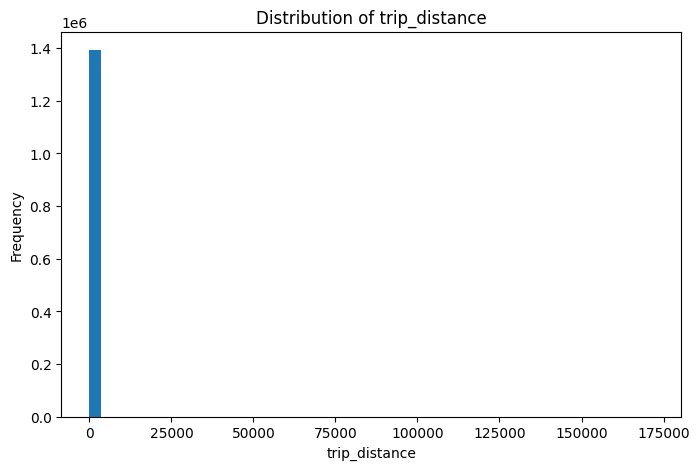

In [16]:
# Distancia de Viaje
calculate_percentiles("trip_distance")
plot_histogram(sample_df, "trip_distance")


Columna: fare_amount
P 1: -2555.199951171875
P 5: 5.099999904632568
P25: 9.300000190734863
P50: 14.199999809265137
P75: 22.600000381469727
P95: 60.5
P99: 863372.125


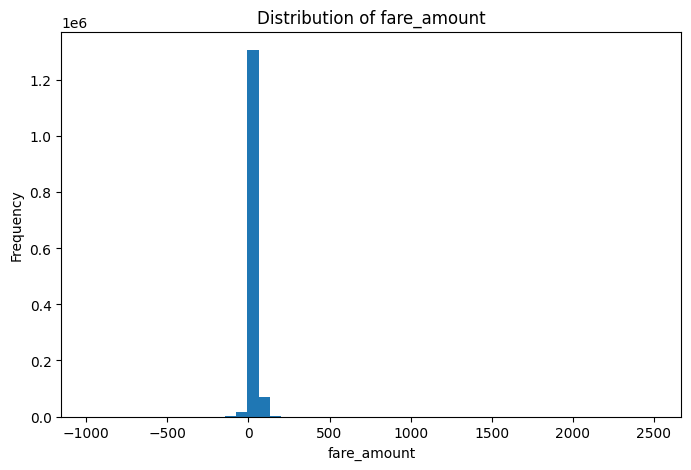

In [17]:
# Total del Viaje
calculate_percentiles("fare_amount")
plot_histogram(sample_df, "fare_amount")


Columna: passenger_count
P 1: 0.0
P 5: 1.0
P25: 1.0
P50: 1.0
P75: 1.0
P95: 3.0
P99: 9.0


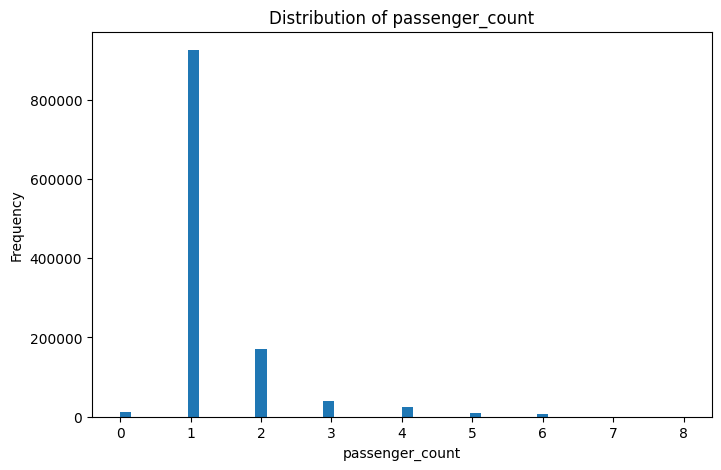

In [18]:
# Cantidad de Pasajeros
calculate_percentiles("passenger_count")
plot_histogram(sample_df, "passenger_count")


Columna: trip_duration_minutes
P 1: -28248298.5
P 5: 3.4
P25: 7.9
P50: 13.1
P75: 21.1
P95: 43.1
P99: 14880.8


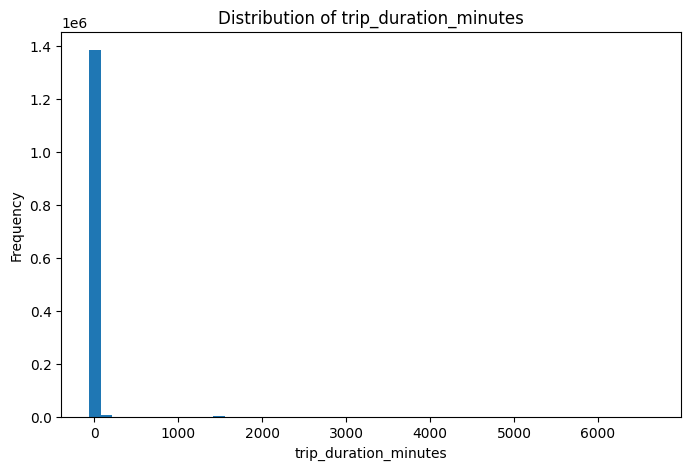

In [19]:
# Tiempo de viaje en minutos
calculate_percentiles("trip_duration_minutes")
plot_histogram(sample_df, "trip_duration_minutes")

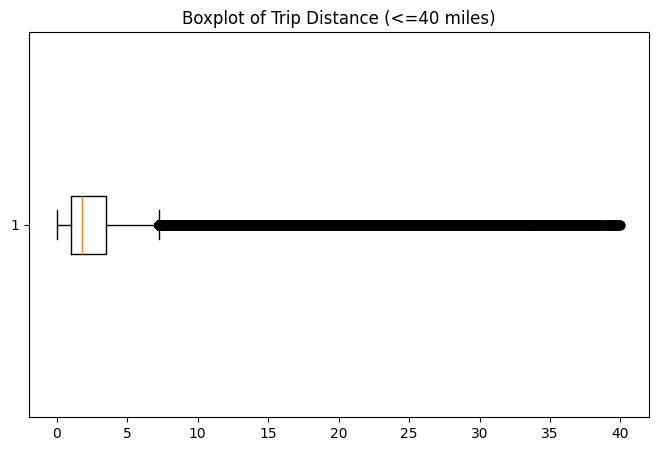

In [20]:
# Gráfico de caja para ver la distribución de distancia de viaje
filtered = sample_df[
    sample_df["trip_distance"] <= 40
]

plt.figure(figsize=(8,5))

plt.boxplot(
    filtered["trip_distance"].dropna(),
    vert=False
)

plt.title("Boxplot of Trip Distance (<=40 miles)")

plt.show()

In [21]:
# Muestra de 10 elementos, con distancias "imposibles"
df.orderBy(
    F.desc("trip_distance")
).show(10, False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+-----------+------------+-----------+---------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|pickup_year|pickup_month|pickup_hour|trip_duration_minutes|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+-----------+-

In [22]:
# Muestra de 10 elementos, con tiempo de viaje "imposibles"
df.orderBy(
    F.asc("trip_duration_minutes")
).show(10, False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+-----------+------------+-----------+---------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|pickup_year|pickup_month|pickup_hour|trip_duration_minutes|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+-----------+-

In [23]:
# Conteo de distancias por segmentos de ~20 millas

df_bucketed = df.withColumn(
    "distance_buckets",
    F.when((F.col("trip_distance") >= 1)   & (F.col("trip_distance") <= 20),    "0001-0020")
     .when((F.col("trip_distance") >= 21)  & (F.col("trip_distance") <= 40),    "0021-0040")
     .when((F.col("trip_distance") >= 41)  & (F.col("trip_distance") <= 60),    "0041-0060")
     .when((F.col("trip_distance") >= 61)  & (F.col("trip_distance") <= 80),    "0061-0080")
     .when((F.col("trip_distance") >= 81)  & (F.col("trip_distance") <= 100),   "0081-0100")
     .when((F.col("trip_distance") >= 101) & (F.col("trip_distance") <= 150),   "0101-0150")
     .when((F.col("trip_distance") >= 151) & (F.col("trip_distance") <= 200),   "0151-0200")
     .when((F.col("trip_distance") >= 201) & (F.col("trip_distance") <= 250),   "0201-0250")
     .when((F.col("trip_distance") >= 251) & (F.col("trip_distance") <= 300),   "0251-0300")
     .when((F.col("trip_distance") >= 301) & (F.col("trip_distance") <= 350),   "0301-0250")
     .when((F.col("trip_distance") >= 351) & (F.col("trip_distance") <= 400),   "0351-0400")
     .when((F.col("trip_distance") >= 401) & (F.col("trip_distance") <= 450),   "0401-0450")
     .when((F.col("trip_distance") >= 451) & (F.col("trip_distance") <= 500),   "0451-0500")
     .when((F.col("trip_distance") >= 501) & (F.col("trip_distance") <= 1000),  "0501-1000")
     .when((F.col("trip_distance") >= 1001) & (F.col("trip_distance") <= 2000), "1001-2000")
     .when((F.col("trip_distance") >= 2001) & (F.col("trip_distance") <= 3000), "2001-3000")
     .when((F.col("trip_distance") >= 3001) & (F.col("trip_distance") <= 4000), "3001-4000")
     .when((F.col("trip_distance") >= 4001) & (F.col("trip_distance") <= 5000), "4001-5000")
     .otherwise(">5K")
)

# Group by the bucket and aggregate
df_bucketed.groupBy("distance_buckets").count().orderBy("distance_buckets").show()

+----------------+---------+
|distance_buckets|    count|
+----------------+---------+
|       0001-0020|105663431|
|       0021-0040|   853263|
|       0041-0060|    29836|
|       0061-0080|     5512|
|       0081-0100|     1632|
|       0101-0150|     1246|
|       0151-0200|      272|
|       0201-0250|      176|
|       0251-0300|       90|
|       0301-0250|       32|
|       0351-0400|       23|
|       0401-0450|       25|
|       0451-0500|       11|
|       0501-1000|       57|
|       1001-2000|       67|
|       2001-3000|       46|
|       3001-4000|       43|
|       4001-5000|       39|
|             >5K| 32723953|
+----------------+---------+



## Creación de dataset para actividades posteriores

In [24]:
# Removemos distancias grandes y con duraciones negativas
df_clean = (
    df
    # Eliminamos tiempos negativos
    .filter(F.col("trip_duration_minutes") >= 0)
    # Eliminamos distancias grandes
    .filter(F.col("trip_distance") <= 40)
)

In [25]:
# count of df_clean
df_clean.count()

139226178

In [28]:
#@title Guardamos el dataframe con sus cambios de tipo
df.write.mode("overwrite").parquet(f"{drive_dir}/clean")

In [29]:
#@title Leer parquet modificado
df = spark.read.parquet(f"{drive_dir}/clean")

In [30]:
#@title Dimensiones generales del dataset unificado

total_records = df.count()
total_columns = len(df.columns)
size_in_bytes = df._jdf.queryExecution().optimizedPlan().stats().sizeInBytes()
print(f"Número de registros: {total_records:,}")
print(f"Información de columnas: {total_columns}")
print(f"Tamaño aproximado: ~{(size_in_bytes / 1024 / 1024 / 1024):.02f} GB")

Número de registros: 139,279,754
Información de columnas: 24
Tamaño aproximado: ~2.87 GB


In [31]:
#@title Esquema del dataset

df.printSchema()

root
 |-- VendorID: byte (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: byte (nullable = true)
 |-- trip_distance: float (nullable = true)
 |-- RatecodeID: byte (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: short (nullable = true)
 |-- DOLocationID: short (nullable = true)
 |-- payment_type: byte (nullable = true)
 |-- fare_amount: float (nullable = true)
 |-- extra: float (nullable = true)
 |-- mta_tax: float (nullable = true)
 |-- tip_amount: float (nullable = true)
 |-- tolls_amount: float (nullable = true)
 |-- improvement_surcharge: float (nullable = true)
 |-- total_amount: float (nullable = true)
 |-- congestion_surcharge: float (nullable = true)
 |-- Airport_fee: float (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-- pickup_year: short (nullable = true)
 |-- pickup_month: byte (nullable = true)
 |-- pick

In [32]:
#@title Muestra 10 registros
df.limit(10).toPandas()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,pickup_hour,trip_duration_minutes
0,1,2023-05-01 00:33:13,2023-05-01 00:53:01,0,7.80,1,N,138,43,1,...,0.00,1.0,51.650002,0.0,1.75,NaN,2023,5,0,19.8
1,1,2023-05-01 00:42:49,2023-05-01 01:11:18,2,8.10,1,N,138,262,1,...,0.00,1.0,57.150002,2.5,1.75,NaN,2023,5,0,28.5
2,1,2023-05-01 00:56:34,2023-05-01 01:13:39,2,9.10,1,N,138,141,1,...,6.55,1.0,64.199997,2.5,1.75,NaN,2023,5,0,17.1
3,2,2023-05-01 00:00:52,2023-05-01 00:20:12,1,8.21,1,N,138,140,1,...,0.00,1.0,47.090000,2.5,1.75,NaN,2023,5,0,19.3
4,1,2023-05-01 00:05:50,2023-05-01 00:19:41,0,7.90,1,N,138,263,1,...,6.55,1.0,59.150002,2.5,1.75,NaN,2023,5,0,13.9
5,1,2023-05-01 00:42:54,2023-05-01 01:04:49,0,10.40,1,N,138,246,1,...,6.55,1.0,69.000000,2.5,1.75,NaN,2023,5,0,21.9
6,2,2023-05-01 00:50:34,2023-05-01 01:12:09,1,9.05,1,N,138,116,1,...,6.55,1.0,64.559998,0.0,1.75,NaN,2023,5,0,21.6
7,1,2023-05-01 00:13:58,2023-05-01 00:18:10,1,0.70,1,N,161,48,1,...,0.00,1.0,14.350000,2.5,0.00,NaN,2023,5,0,4.2
8,2,2023-04-30 23:48:31,2023-04-30 23:57:35,1,2.38,1,N,249,231,2,...,0.00,1.0,17.100000,2.5,0.00,NaN,2023,4,23,9.1
9,2,2023-05-01 00:28:47,2023-05-01 00:39:33,1,2.92,1,N,114,230,2,...,0.00,1.0,19.900000,2.5,0.00,NaN,2023,5,0,10.8
